# Metamorphic Testing of the NESTML AMAT Neuronal Model 

In [1]:
import hypothesis 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nest
from pathlib import Path
from dataclasses import dataclass
import pynestml
from typing import Literal, Mapping, Sequence

from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils
from pynestml.codegeneration.nest_tools import NESTTools

print("Hypothesis version:", hypothesis.__version__)
print("NEST version:", nest.__version__)


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

Hypothesis version: 6.163.0
NEST version: 3.9.0-post0.dev14


# Build and validate the NESTML AMAT neuronal model 

In [2]:
def build_nestml_model(
    source_path: Path,
    module_name: str,) -> tuple[str, str]:
    
    if not source_path.exists():
        raise FileNotFoundError(f"NESTML source not found: {source_path}")

    generated_module, generated_model = NESTCodeGeneratorUtils.generate_code_for( # nest call to compile nestml c++ script 
        str(source_path),
        module_name=module_name,
        logging_level="INFO",)

    try:
        nest.Install(generated_module)
        print(f"Successfully installed module: '{generated_module}'")
    except nest.kernel.NESTError:
        print(f"Module '{generated_module}' is already installed. Skipping installation step.")

    # Verify the MODEL name is loaded and recognized by the NEST engine
    if generated_model not in nest.Models():
        raise RuntimeError(
            f"Generation completed, but model '{generated_model}' is missing from nest.Models()."
        )
    
    # return module, name 
    return generated_module, generated_model

# defining global variables 
nest_model = "amat2_psc_exp"
nestml_source = Path("neurons_nestml/amat_neuron.nestml")
nestml_module = "nestml_amat_module"
resolution_ms = 0.01

# calling build function
module_name, nestml_model = build_nestml_model(
    nestml_source,
    nestml_module,
)

print("Loaded module:", module_name)
print("Generated model:", nestml_model)
print("NESTML recordables:", nest.GetDefaults(nestml_model)["recordables"])

[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/neurons_nestml/amat_neuron.nestml
[3,GLOBAL, INFO]: Target platform code will be generated in directory: "/Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target"
[4,GLOBAL, INFO]: Target platform code will be installed in directory: "/var/folders/jk/36jftn6s3yz6ks1zj2zdlry40000gn/T/nestml_target_nnxziti3"

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[5,GLOBAL, INFO]: The NEST Simulator version was automatically detected as: main
[6,GLOBAL, INFO]: Given template root path is not an absolute path. Creating the absolute path with default templates direc

INFO:root:Analysing input:
INFO:root:{
    "dynamics": [
        {
            "expression": "V_th_alpha_1' = (-V_th_alpha_1) / tau_1",
            "initial_values": {
                "V_th_alpha_1": "0"
            }
        },
        {
            "expression": "V_th_alpha_2' = (-V_th_alpha_2) / tau_2",
            "initial_values": {
                "V_th_alpha_2": "0"
            }
        },
        {
            "expression": "V_m' = ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "V_th_v_aux' = (-V_th_v_aux) / tau_v + beta * ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_th_v_aux": "0 / 1.0"
            }
        },


[11,GLOBAL, INFO]: Starting code generation for model "amat_neuron_nestml"
[12,amat_neuron_nestml, INFO, [124:0;238:0]]: Starts processing of the model "amat_neuron_nestml"
[13,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/amat_neuron_nestml.cpp
[14,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/amat_neuron_nestml.h
[15,amat_neuron_nestml, INFO, [124:0;238:0]]: Successfully generated code for the model: "amat_neuron_nestml" in: "/Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target" !
[16,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/CMakeLists.txt
[17,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/nestml_amat_module.h
[18,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/nestml_amat_module.cpp
[19,GLOBAL, IN

/Users/angusgray/Desktop/JSC/nest-simulator/mamba/lib/python3.12/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Models is deprecated and will be removed in a future version of NEST.
Please use nest.node_models or nest.synapse_models instead!


## NEST NESTML parameter config

Building dataclass configs for NESTML and NEST models, with `Frozen=True` and `Literal[]` so the data and variables cannot be influenced and affected in downstream simulations


In [8]:
# restricts so only modeltype can be the following 
ModelType = Literal["nest", "nestml"]

@dataclass(frozen=True) # pass AMATConfig into both nestml and nest configs, ensures params are kept the same 
class AMATConfig:
    pulse_times_ms: tuple[float, ...] = (200.0, 220.0, 400.0, 460.0)
    pulse_amplitude_pa: float = 1000.0
    pulse_width_ms: float = 1.0
    simulation_time_ms: float = 500.0
  
    tau_m_ms: float = 10.0
    gamma: float = 1.5
    B: float = 4.0
    
    E_L_mv: float = -70.0
    resting_threshold_offset_mv: float = 5.0
    
    alpha_1_mv: float = 10.0
    alpha_2_mv: float = 0.0

@dataclass
class SimulationResult: # 
    model_name: str
    ModelType: ModelType
    events: Mapping
    spikes: Mapping
    parameters: dict[str, float]

# Construct Parameters for Neuronal Model 

In [9]:
def identify_model_type(model_name: str, nestml_model_name: str) -> ModelType: 
    if model_name == nest_model:
        return "nest"   # classifying what model we are running for the specified sim
    if model_name == nestml_model_name:
        return "nestml"
    raise ValueError(f"Unsupported AMAT model: {model_name}")

def build_model_parameters(
    model_name: str,
    ModelType: ModelType,
    config: AMATConfig,
) -> dict[str, float]:
    """Translate shared conceptual parameters to each model's public API."""   # public API has a frozen set of params?
    defaults = nest.GetDefaults(model_name)
    tau_m = float(defaults["tau_m"])

    return {
        "tau_m": tau_m,
        "tau_v": config.gamma * tau_m, 
        "beta": config.B / tau_m,
        "alpha_1": config.alpha_1_mv,
        "alpha_2": config.alpha_2_mv,
        "omega": config.resting_threshold_offset_mv,
    }

def install_generated_module(module_name: str) -> None:
    """Install the generated module if it is not already loaded.""" # ensure the generated module is in the kernel 
    try:
        nest.Install(module_name)
    except Exception as exc:
        message = str(exc).lower()
        if "loaded already" not in message and "already loaded" not in message: # should be used for nest, nestml will be built and already present. 
            raise


install_generated_module(module_name)
nest_model = "amat2_psc_exp"
model_type = identify_model_type(nest_model, nestml_model) # utilising helper functions defined in the cell above 
config = AMATConfig() # establish amat config 
parameters = build_model_parameters(nestml_model, model_type, config)
print("Parameters loaded.") 


KernelException: Network elements have been created, so external modules can no longer be imported. Call ResetKernel() first.

# Firing rate

Metamorphic Testing: Scenario 1 

Scenario 1: Increase of I(e) leads to increase of synchrony? 

https://nestml.readthedocs.io/en/latest/tutorials/gl_model/gl_model_tutorial.html

In this tutorial they use the Galves–Löcherbach neuronal model. At every simulation steo it's membrane potenital is passed thtorugh a firing-probability function phi(Vm) and a random number determines if it spikes, this provides a robustness as validity to the network. The tutorial compares constant current delivered to multiple stochastic neurons, the same 'frozen' poisson spike train delivered to all neurons. Because the frozen poisson input contians identifcalbe temporal events, spikes tend to cluster around theose events. The resulting raster plot has clear vertical bands as shown below.

This should correspond to the Φ(Vm) function in the neuron (see plot below for the theoretical curve). Please note that in the literature, Φ is sometimes defined as a probability of firing function with values between 0 and 1, but we here define it as giving the firing rate (in units of s−1).

A corrected frozen-input experiment
This version tests whether AMAT neurons starting from different initial membrane potentials become more similar when driven by the same frozen Poisson input.
That is a valid behavioural investigation, although it is not yet a strong metamorphic relation.

In [6]:
from dataclasses import dataclass
from typing import Mapping

import matplotlib.pyplot as plt
import nest
import numpy as np


@dataclass
class PopulationResult:
    spike_times: np.ndarray
    spike_senders: np.ndarray
    membrane_times: np.ndarray
    membrane_voltage: np.ndarray
    membrane_senders: np.ndarray


def install_module_safely(module_name: str) -> None:
    """Install the generated NESTML module after a kernel reset."""

    try:
        nest.Install(module_name)
    except Exception as exc:
        if "already" not in str(exc).lower():
            raise


def supported_parameters(
    model_name: str,
    requested: Mapping[str, float],
) -> dict[str, float]:
    """Return only parameters exposed by the selected NEST model."""

    defaults = nest.GetDefaults(model_name)

    unsupported = [
        name for name in requested
        if name not in defaults
    ]

    if unsupported:
        raise ValueError(
            f"Unsupported parameters for {model_name}: {unsupported}"
        )

    return dict(requested)


def run_amat_population(
    *,
    model_name: str,
    module_name: str,
    model_parameters: Mapping[str, float],
    number_of_neurons: int = 20,
    stimulus_type: str = "constant",
    constant_current_pa: float = 500.0,
    poisson_rate_hz: float = 2000.0,
    synaptic_weight_pa: float = 200.0,
    simulation_time_ms: float = 500.0,
    resolution_ms: float = 0.1,
    seed: int = 1000,
    random_initial_states: bool = True,
) -> PopulationResult:
    """Run isolated copies of the same NESTML AMAT model."""

    nest.ResetKernel()
    nest.set_verbosity("M_ERROR")

    nest.SetKernelStatus({
        "resolution": resolution_ms,
        "rng_seed": seed,
        "local_num_threads": 1,
    })

    install_module_safely(module_name)

    parameters = supported_parameters(
        model_name,
        model_parameters,
    )

    neurons = nest.Create(
        model_name,
        number_of_neurons,
        params=parameters,
    )

    if random_initial_states:
        rng = np.random.default_rng(seed)

        resting_voltage = float(parameters.get("E_L", -70.0))

        initial_voltages = rng.uniform(
            resting_voltage,
            resting_voltage + 10.0,
            size=number_of_neurons,
        )

        nest.SetStatus(
            neurons,
            [{"V_m": float(value)} for value in initial_voltages],
        )

    if stimulus_type == "constant":
        nest.SetStatus(
            neurons,
            {"I_e": constant_current_pa},
        )

    elif stimulus_type == "frozen_poisson":
        poisson = nest.Create(
            "poisson_generator",
            params={"rate": poisson_rate_hz},
        )

        # The parrot ensures the same realised Poisson events are
        # distributed to all AMAT neurons.
        parrot = nest.Create("parrot_neuron")

        nest.Connect(poisson, parrot)

        nest.Connect(
            parrot,
            neurons,
            conn_spec="all_to_all",
            syn_spec={"weight": synaptic_weight_pa},
        )

    else:
        raise ValueError(
            "stimulus_type must be 'constant' or 'frozen_poisson'"
        )

    available_recordables = set(
        nest.GetDefaults(model_name)["recordables"]
    )

    requested = [
        "V_m",
        "V_th",
        "V_th_alpha_1",
        "V_th_alpha_2",
        "V_th_v",
    ]

    recordables = [
        variable
        for variable in requested
        if variable in available_recordables
    ]

    multimeter = nest.Create(
        "multimeter",
        params={
            "interval": resolution_ms,
            "record_from": recordables,
        },
    )

    spike_recorder = nest.Create("spike_recorder")

    nest.Connect(multimeter, neurons)
    nest.Connect(neurons, spike_recorder)

    nest.Simulate(simulation_time_ms)

    voltage_events = multimeter.get("events")
    spike_events = spike_recorder.get("events")

    return PopulationResult(
        spike_times=np.asarray(spike_events["times"]),
        spike_senders=np.asarray(spike_events["senders"]),
        membrane_times=np.asarray(voltage_events["times"]),
        membrane_voltage=np.asarray(voltage_events["V_m"]),
        membrane_senders=np.asarray(voltage_events["senders"]),
    )

config = AMATConfig()

amat_parameters = {
    "tau_m": config.tau_m_ms,
    "tau_v": config.gamma * config.tau_m_ms,
    "beta": config.B / config.tau_m_ms,
    "alpha_1": config.alpha_1_mv,
    "alpha_2": config.alpha_2_mv,
    "E_L": config.E_L_mv,
    "omega": config.resting_threshold_offset_mv,
}

constant_result = run_amat_population(
    model_name=nestml_model,
    module_name=module_name,
    model_parameters=amat_parameters,
    number_of_neurons=20,
    stimulus_type="constant",
    constant_current_pa=500.0,
)

frozen_result = run_amat_population(
    model_name=nestml_model,
    module_name=module_name,
    model_parameters=amat_parameters,
    number_of_neurons=20,
    stimulus_type="frozen_poisson",
    poisson_rate_hz=2000.0,
    synaptic_weight_pa=200.0,
)

/Users/angusgray/Desktop/JSC/nest-simulator/mamba/lib/python3.12/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Provided for backward compatibility only. Set `nest.verbosity = nest.VerbosityLevel.XYZ` instead.
/Users/angusgray/Desktop/JSC/nest-simulator/mamba/lib/python3.12/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
SetStatus() is deprecated and will be removed in a future version of NEST. Instead of SetStatus(nrns|conns, args), use nrns|conns.set(args).


# Raster plots 

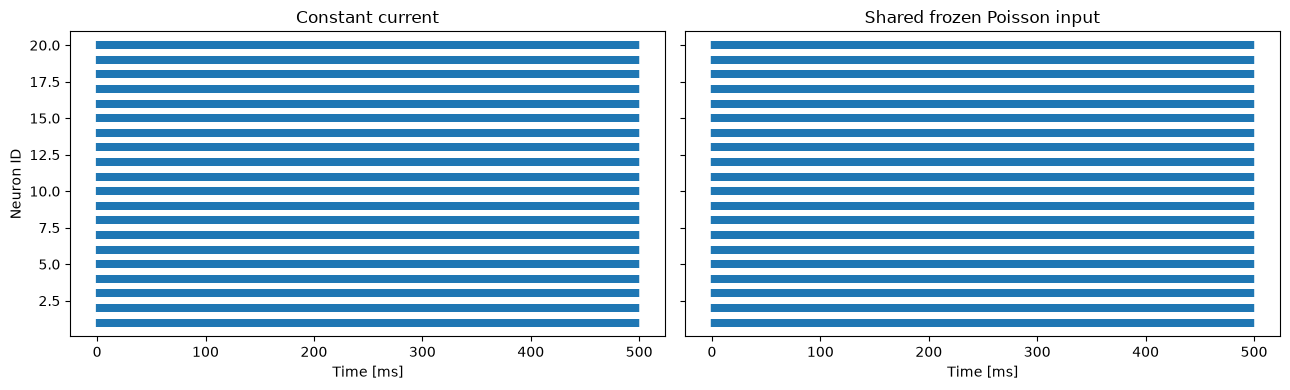

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4),
    sharex=True,
    sharey=True,
)

axes[0].scatter(
    constant_result.membrane_times,
    constant_result.membrane_senders,
    marker="|",
)

axes[0].set_title("Constant current")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("Neuron ID")

axes[1].scatter(
    frozen_result.membrane_times,
    frozen_result.membrane_senders,
    marker="|",
)

axes[1].set_title("Shared frozen Poisson input")
axes[1].set_xlabel("Time [ms]")

plt.tight_layout()
plt.show()